In [ ]:
from common import *
import io
from numpy.typing import NDArray
from matplotlib.cbook import boxplot_stats
from pprint import pprint

In [ ]:
ula3_5 = """
alpha	pdoa01	pdoa12	pdoa02
-90	33.4421	69.3738	-14.8629
-90	35.0479	80.9679	-12.6538
-90	32.9895	80.7491	-13.5476
-90	33.456	-85.1141	-12.8579
-90	34.2958	-81.7776	-12.3053
-90	34.6933	-77.1326	-11.7034
-90	32.6937	72.8007	-14.6121
-90	36.5549	79.9138	-12.1181
-90	41.9133	-82.8096	-9.32624
-90	41.2032	80.6506	-10.2108
-90	38.2715	68.529	-13.0022
-90	38.4059	72.9301	-12.2044
-90	36.7689	73.5971	-12.7707
-90	36.5577	75.5286	-12.5953
-90	36.7034	74.2524	-12.7049
-90	36.9902	74.6358	-12.5344
-90	37.228	72.7981	-12.7008
-90	37.3005	72.622	-12.6981
-90	37.5188	72.0103	-12.7043
-90	37.8057	71.6138	-12.6515
-90	37.6142	72.2533	-12.6274
-90	37.1148	74.4626	-12.5067
-90	37.6838	72.9225	-12.4968
-90	36.9287	76.2623	-12.35
-90	39.7043	73.6578	-11.5827
-90	36.6928	70.0341	-13.3734
-90	35.7787	65.3112	-14.6773
-90	25.2771	-72.3055	-15.2383
-90	34.5151	75.5484	-13.4439
-90	31.9403	-64.9769	-10.8681
-90	29.0659	73.0102	-16.1949
-90	46.3557	-69.513	-6.11647
-90	44.4183	-75.3473	-7.68841
-90	44.1831	85.8917	-8.78931
-60	21.8163	-63.9918	-15.2808
-60	26.2799	-69.2737	-14.2564
-60	26.4508	-66.2279	-13.5843
-60	27.0751	83.0597	-16.0265
-60	24.8692	-74.2622	-15.7227
-60	24.5672	-72.4563	-15.597
-60	25.0028	-76.5552	-15.9605
-60	25.0604	-76.1908	-15.8875
-60	25.4505	-82.5634	-16.3151
-60	25.7215	-64.1663	-13.4757
-60	26.195	-64.3416	-13.2962
-60	28.0236	-66.5955	-12.9408
-60	32.286	80.0205	-13.9154
-60	31.3553	-81.1131	-13.5221
-60	28.7868	-74.3387	-13.9258
-60	30.0278	-71.0401	-12.8658
-60	27.8618	-65.172	-12.7156
-60	26.6798	-67.0501	-13.6461
-60	27.0551	-68.3669	-13.7306
-60	29.4587	-70.1509	-12.968
-60	29.5762	-70.1595	-12.9175
-60	29.4549	-69.8822	-12.9223
-60	27.1164	-66.3689	-13.3073
-60	29.44	-69.1261	-12.7928
-60	27.3841	-67.2819	-13.369
-60	27.0309	-66.1099	-13.2926
-60	27.3816	-67.2607	-13.3667
-60	27.5668	-66.8284	-13.1961
-60	26.8562	-66.6448	-13.4829
-60	29.6088	-70.4284	-12.9486
-60	29.0684	-69.7055	-13.0637
-60	27.2002	-66.3214	-13.2592
-60	27.653	-66.7299	-13.1365
-60	27.8438	-65.922	-12.8831
-60	28.733	-69.2987	-13.1417
-60	29.424	-71.0611	-13.1378
-30	15.4099	-53.3825	-15.5728
-30	12.0422	-48.2243	-15.5793
-30	10.8578	-47.2342	-15.8371
-30	8.93962	-47.3743	-16.8703
-30	12.2968	-50.6459	-16.2693
-30	16.6401	-58.824	-16.536
-30	17.0194	-58.1847	-16.1722
-30	19.2514	-60.9801	-15.8056
-30	12.2056	-51.3261	-16.5387
-30	8.84884	-48.2116	-17.2115
-30	15.0657	-56.7772	-16.7562
-30	17.8512	-60.7472	-16.4384
-30	18.1919	-61.5865	-16.4798
-30	17.4207	-60.6791	-16.6349
-30	16.4074	-59.9158	-16.9459
-30	15.0559	-57.3666	-16.9299
-30	29.5446	69.219	-16.6162
-30	-2.04452	-35.462	-17.9355
-30	8.72218	-46.2065	-16.5665
-30	10.8407	-51.7553	-17.3772
-30	13.5407	-53.7687	-16.6338
-30	18.9745	-60.786	-15.8924
-30	13.3392	-52.6713	-16.394
-30	18.2084	-62.4106	-16.6734
-30	21.5646	-69.2094	-16.4792
-30	18.4766	-61.6963	-16.3656
-30	17.4157	-59.7775	-16.4032
-30	16.7215	-58.5311	-16.4159
-30	15.3481	-56.0812	-16.4145
-30	17.0689	-59.5932	-16.5271
-30	15.5721	-56.7204	-16.4861
-30	14.9727	-55.4131	-16.4068
-30	16.0771	-57.4129	-16.4294
-30	17.6071	-59.6618	-16.2778
-30	17.531	-60.4534	-16.5215
0	-9.33882	9.93815	0.29524
0	-10.2048	9.85723	-0.170736
0	-9.08118	10.4259	0.662699
0	-8.84913	9.20682	0.176611
0	-9.5913	9.64212	0.0251476
0	-9.7713	9.79725	0.0131117
0	-9.32459	9.58759	0.129664
0	-9.32537	9.16466	-0.0792399
0	-9.59383	9.35048	-0.120227
0	-9.43929	9.57036	0.0645395
0	-9.5388	9.49607	-0.0212133
0	-9.66408	9.47152	-0.0947357
0	-9.69889	9.59846	-0.049447
0	-9.11166	9.32764	0.106838
0	-9.28365	9.43689	0.0756332
0	-9.534	9.3475	-0.0921461
0	-9.28532	9.11246	-0.0851072
0	-9.35242	9.21269	-0.0692052
0	-9.92603	9.56139	-0.179261
0	-9.69925	9.60207	-0.047903
0	-9.43466	9.52999	0.0470289
0	-9.76057	9.37538	-0.189894
0	-9.19456	9.3279	0.0658694
0	-9.31416	9.27755	-0.0180941
0	-8.9369	9.176	0.117815
0	-9.70036	9.42589	-0.135083
0	-9.88311	9.55008	-0.164025
0	-9.74876	9.56136	-0.0928334
0	-9.65313	9.13704	-0.254623
0	-9.90281	9.26205	-0.315787
0	-9.75843	9.07727	-0.336561
0	-9.60498	9.12147	-0.238514
0	-9.24599	9.08812	-0.0779782
0	-9.57688	8.92521	-0.321724
0	-9.57432	9.43993	-0.0663098
0	-9.60641	9.50203	-0.0519948
0	-9.39008	9.15119	-0.117893
0	-9.65879	9.39879	-0.127587
0	-9.21742	8.87	-0.171322
0	-9.58177	9.49318	-0.0434558
0	-9.17559	9.50732	0.163799
0	-9.29756	9.40394	0.0521885
0	-7.42008	11.4222	1.97412
30	21.4652	25.8409	23.635
30	21.8695	25.3978	23.6221
30	21.7025	25.4599	23.5673
30	22.0232	25.6095	23.8039
30	22.183	25.6404	23.9007
30	22.2208	26.3808	24.2842
30	22.1556	26.0974	24.1115
30	22.2036	26.4912	24.3292
30	22.4822	26.4698	24.4599
30	22.182	25.8577	24.0067
30	21.9897	26.2119	24.0834
30	21.9144	26.5943	24.2326
30	22.3984	26.1156	24.2434
30	22.3036	26.3354	24.3033
30	21.909	26.4128	24.1412
30	21.9247	25.6297	23.764
30	21.5661	25.4499	23.4937
30	21.5811	25.5128	23.5323
30	21.7344	25.4088	23.5588
30	21.6253	25.7453	23.6688
30	21.5955	25.4554	23.5112
30	21.7449	25.3704	23.545
30	22.6024	26.0193	24.3001
30	22.436	26.6584	24.5299
30	22.3958	25.6022	23.989
30	21.6397	25.4182	23.5152
30	22.3156	26.1719	24.2292
30	21.8993	26.42	24.14
30	22.0996	25.8036	23.9378
30	21.8707	25.7897	23.8153
30	22.54	25.774	24.1468
30	22.4673	24.8099	23.6333
30	21.7247	27.5739	24.6154
30	21.9761	27.6458	24.7786
60	32.9183	37.3743	-25.1355
60	32.0021	37.2052	-25.6377
60	31.8778	36.9887	-25.7927
60	32.1448	36.5767	-25.8503
60	32.1464	37.0018	-25.6604
60	32.307	36.9625	-25.6024
60	32.4184	37.446	-25.3369
60	32.9767	37.1821	-25.1933
60	38.2175	35.7606	-23.4825
60	36.8319	37.393	-23.3675
60	36.5	41.0549	-21.9742
60	38.6313	37.2442	-22.6585
60	38.5589	37.1393	-22.7343
60	35.7106	36.2623	-24.3567
60	34.155	37.3166	-24.5932
60	30.5639	41.1141	-24.6434
60	31.4437	39.43	-24.9357
60	33.0906	38.6374	-24.5077
60	31.7731	39.9787	-24.5484
60	31.2052	41.0501	-24.3672
60	30.5177	43.26	-23.7934
60	30.9262	40.7938	-24.6051
60	32.9586	47.8235	-20.9431
60	39.4377	40.3759	-21.0068
60	39.0169	41.1678	-20.8602
60	30.8613	46.7689	-22.2852
60	33.3548	47.976	-20.7109
60	33.4411	45.9945	-21.3967
60	32.8011	46.7425	-21.4076
60	33.1222	48.0064	-20.8042
60	33.5609	47.6602	-20.733
60	33.0546	48.0953	-20.8024
60	32.5244	47.6485	-21.2018
60	32.7094	46.8776	-21.3988
60	33.4867	46.4047	-21.2239
60	33.2	47.4781	-20.9597
60	32.8416	46.9013	-21.3306
90	49.1431	-45.5557	1.21499
90	49.3753	-45.754	1.22154
90	49.583	-45.9234	1.23055
90	52.1879	-44.3882	2.59349
90	44.623	-42.5811	0.739546
90	39.1938	-43.6197	-1.65971
90	39.1871	-43.6294	-1.66535
90	39.68	-43.747	-1.51802
90	39.9161	-43	-1.15572
90	41.4949	-44.4655	-1.08665
90	39.5269	-44.0089	-1.67161
90	39.993	-44.3882	-1.62769
90	39.697	-44.1642	-1.66152
90	39.5734	-44.7073	-1.90328
90	39.7713	-45.0413	-1.94522
90	40.4502	-46.0498	-2.03884
90	40.7297	-46.3912	-2.05166
90	40.9919	-47.7701	-2.42151
90	41.0802	-49.4333	-2.93892
90	41.9539	-50.5642	-2.97518
90	41.8167	-50.8908	-3.12986
90	42.0179	-50.6892	-2.99069
90	43.5342	-52.3518	-2.95133
90	47.021	-56.834	-3.02329
90	48.0471	-54.1467	-1.91531
90	48.6723	-54.2056	-1.7241
90	46.6738	-54.3361	-2.43572
90	47.6383	-53.9305	-1.9885
90	53.237	-50.6148	0.808461
90	53.1728	-50.215	0.915716
90	54.517	-50.701	1.15783
90	53.5141	-49.827	1.14325
90	52.8211	-48.7963	1.27136
90	54.1606	-52.1128	0.614335
90	52.825	-56.9808	-1.1945
90	55.1219	-56.7171	-0.446966
90	58.2078	-61.1808	-0.749929
90	46.2689	-60.9258	-4.34104
"""

In [ ]:
ula20 = """
alpha	pdoa01	pdoa12	pdoa02
-90	29.7078	-45.9398	-6.38508
-90	27.2241	-42.0963	-6.08445
-90	26.9295	-44.0755	-7.00438
-90	22.6877	-38.6435	-6.87326
-90	24.5388	-44.3985	-8.16696
-90	28.645	-51.1057	-8.62659
-90	26.4795	-50.5492	-9.35999
-90	25.8194	-49.9497	-9.4796
-90	23.7725	-47.3097	-9.53737
-90	27.279	-50.4656	-8.99738
-90	27.813	-55.1102	-10.1768
-90	28.5968	-54.3515	-9.5896
-90	27.3992	-44.7568	-6.97555
-90	27.9699	-47.9531	-7.81275
-90	18.5489	-46.0859	-11.6067
-90	31.9693	-88.9141	-13.5593
-90	19.6827	-42.4662	-9.71046
-90	26.9366	-47.7282	-8.27798
-90	27.0402	-54.1918	-10.2398
-90	25.8535	-49.9277	-9.44368
-90	28.871	-54.3697	-9.4728
-90	29.988	-61.4662	-10.8953
-90	30.9438	-67.1874	-11.7885
-90	24.0874	-49.7481	-10.1793
-90	27.304	-52.0917	-9.50456
-90	27.6313	-53.2984	-9.70318
-90	29.5882	-58.1248	-10.1819
-90	32.1991	-59.8212	-9.50578
-90	32.1109	-52.933	-7.63035
-90	32.8506	-61.6079	-9.68913
-90	30.9111	-57.0268	-9.35414
-90	28.5747	-56.3121	-10.1661
-90	35.8562	-58.9017	-7.7428
-90	34.7683	-55.4574	-7.22184
-60	25.1504	16.8459	20.909
-60	26.5267	13.4251	19.8562
-60	24.2239	19.8467	21.9999
-60	22.1726	35.6175	28.6489
-60	22.8206	34.5154	28.4811
-60	22.3464	34.1022	28.0765
-60	22.5466	33.4788	27.9663
-60	22.6773	29.5483	26.1328
-60	21.6274	32.3997	26.9379
-60	20.4795	37.3296	28.5413
-60	20.49	37.1017	28.4417
-60	19.7666	39.5941	29.2266
-60	19.9767	37.853	28.5478
-60	19.5218	39.1411	28.9111
-60	19.5946	38.1126	28.4876
-60	20.1136	40.0101	29.5666
-60	21.1635	36.9955	28.8035
-60	21.4343	38.726	29.6914
-60	22.0202	35.4715	28.5815
-60	18.4303	38.3429	27.959
-60	22.0551	20.1948	21.1266
-60	18.1487	28.6809	23.3097
-60	16.2664	35.3975	25.4936
-60	20.5785	25.3134	22.9651
-60	20.4507	26.942	23.6584
-60	25.7099	19.4369	22.5476
-60	24.1961	21.7185	22.9907
-60	27.0442	19.3596	23.1733
-60	22.299	26.3062	24.3115
-60	21.7908	21.1267	21.4751
-30	-20.5359	-37.1172	-28.5089
-30	-18.6468	-38.9513	-28.3316
-30	-23.4105	-34.6071	-28.8689
-30	-22.0872	-37.8378	-29.6692
-30	-27.3977	-33.0502	29.7535
-30	-23.5188	-36.4799	-29.8259
-30	-23.4062	-34.5753	-28.8372
-30	-21.1751	-37.3908	-29.005
-30	-25.7275	-29.7825	-27.7729
-30	-27.3889	-29.2954	-28.3505
-30	-10.5799	-53.6897	-29.6626
-30	-9.19939	-55.0348	-29.3307
-30	-10.6824	-55.065	29.8243
-30	-16.2831	-48.8148	28.8905
-30	-38.0985	-23.2197	29.5737
-30	-18.5287	-42.1109	-29.6607
-30	-28.879	-28.1419	-28.5242
-30	-20.9456	-36.7097	-28.5541
-30	-20.2535	-37.8855	-28.7351
-30	-25.7855	-32.1612	-28.9646
-30	-23.3777	-34.0568	-28.6194
-30	-18.2745	-40.0055	-28.5787
-30	-15.9924	-42.6081	-28.4495
-30	-17.6671	-40.8911	-28.6556
-30	-18.1797	-40.4761	-28.7081
-30	-17.4069	-40.9256	-28.5032
-30	-16.79	-42.3656	-28.8083
-30	-12.1247	-48.8101	-28.7951
-30	-14.5185	-45.1802	-28.7153
-30	-18.4701	-41.3062	-29.2452
-30	-11.8395	-49.3111	-28.8271
0	-10.4619	7.52602	-1.44599
0	-3.01248	10.9414	3.93658
0	-5.21844	9.90068	2.3243
0	-5.71274	10.4197	2.33437
0	-9.91596	9.30829	-0.295538
0	-10.4464	9.76255	-0.333138
0	-6.78789	8.33669	0.770042
0	-7.6444	7.89751	0.128838
0	-9.90683	8.37374	-0.75559
0	-12.7236	7.06757	-2.78314
0	-7.16576	9.54476	1.17884
0	-6.94192	9.45736	1.24415
0	-5.13682	10.8405	2.82409
0	-9.31602	8.81688	-0.24737
0	-6.53236	9.39882	1.41779
0	-9.57256	9.23058	-0.166881
0	-7.47304	10.055	1.27606
0	-6.36385	9.98327	1.79329
0	-6.41723	9.82103	1.68854
0	-5.28187	9.38863	2.03584
0	-5.31405	10.5062	2.56875
0	-7.60995	9.81478	1.09048
0	-6.29302	10.3369	2.00061
0	-6.34188	10.8607	2.2324
0	-4.71518	10.0734	2.65503
0	-7.7427	8.992	0.619533
0	-8.83949	8.90398	0.0349862
0	-8.23169	9.18262	0.471131
0	-8.28715	8.04992	-0.114891
0	-10.7808	7.04053	-1.84359
0	-8.42127	8.06768	-0.176176
0	-5.9877	7.93282	0.967207
0	-5.9665	9.26181	1.63625
30	23.635	34.8089	29.0703
30	22.9774	35.0774	28.854
30	22.4395	33.4849	27.8246
30	23.6466	32.1035	27.7989
30	23.2986	32.8337	27.9635
30	22.8738	32.684	27.667
30	23.8425	32.1284	27.9129
30	23.3854	31.4269	27.3368
30	23.1785	33.1541	28.0483
30	23.8966	31.5203	27.643
30	24.1562	30.8357	27.4478
30	24.2248	32.5538	28.3113
30	23.9864	32.7428	28.2786
30	24.0698	32.5741	28.2412
30	23.2524	32.9891	28.0152
30	22.717	33.6192	28.0301
30	23.3762	33.5728	28.3529
30	22.2883	34.1341	28.0489
30	23.2539	33.2755	28.1506
30	22.5584	33.452	27.8641
30	22.8592	32.8795	27.7574
30	22.7143	33.7398	28.0887
30	23.1482	35.2006	29.0014
30	22.4554	35.5174	28.7855
30	22.2603	34.3865	28.1538
30	21.6745	33.7807	27.5579
30	21.7381	34.4266	27.9042
30	23.7082	30.6711	27.1447
30	24.0483	31.8714	27.8904
30	23.5392	31.4492	27.429
30	23.3527	31.8992	27.5407
30	22.9718	33.221	27.9781
60	36.5125	-66.9898	-9.3125
60	28.3592	-73.8041	-14.0387
60	33.4085	88.5648	-12.9868
60	29.6927	-74.8573	-13.5873
60	31.1675	-79.5273	-13.4543
60	29.3328	-68.6541	-12.7407
60	29.5175	-68.458	-12.6129
60	35.8378	-84.4095	-11.8111
60	33.4468	-82.6723	-12.6964
60	33.8847	83.784	-12.9609
60	33.2748	87.0932	-13.0886
60	34.0733	-82.9412	-12.4729
60	34.8354	-83.6297	-12.1775
60	34.4936	-74.6129	-11.4781
60	34.0294	-83.9781	-12.557
60	35.8637	75.4572	-12.8609
60	35.9773	75.381	-12.8358
60	36.619	75.0716	-12.6128
60	33.6828	79.4609	-13.3361
60	34.5003	80.9049	-12.8725
60	35.6583	78.1489	-12.6317
60	33.3953	-82.7211	-12.7349
60	33.7761	-85.4239	-12.7041
60	35.5238	-73.5865	-10.8791
60	32.6798	-61.7315	-9.7708
60	33.2779	-57.2438	-8.3625
60	33.5285	-70.2044	-11.1724
60	34.9425	-70.4972	-10.6171
60	33.1085	-67.3278	-10.815
60	33.8884	-73.0471	-11.4804
60	35.3187	80.4699	-12.5694
60	34.0573	-82.6065	-12.4279
60	32.5436	-74.0065	-12.1858
60	33.0163	-78.824	-12.5326
90	45.1666	-29.0869	6.39265
90	44.7331	-27.6063	6.89036
90	43.5375	-31.6287	4.69771
90	39.266	-31.7503	3.04346
90	41.375	-33.8014	3.02013
90	40.6711	-23.3263	7.36406
90	40.3542	-33.6043	2.68569
90	38.1953	-26.9828	4.71508
90	25.784	-23.1991	1.1931
90	25.0775	-19.3936	2.6108
90	26.1565	-20.6344	2.5253
90	27.0126	-35.7091	-3.71977
90	37.8998	-29.1776	3.60473
90	39.2307	-33.1367	2.44194
90	41.4975	-28.9747	5.10314
90	44.7706	-27.2092	7.06869
90	43.6725	-31.745	4.70188
90	44.8684	-29.8676	5.93603
90	40.6775	-32.9464	3.08898
90	41.4415	-28.9409	5.0925
90	39.9965	-31.5972	3.39663
90	38.3237	-31.2931	2.86345
90	39.817	-34.3015	2.20163
90	37.642	-32.9571	1.89192
90	38.1596	-34.0865	1.64104
90	38.865	-34.9472	1.56584
90	39.4494	-32.5922	2.76691
90	38.4959	-32.0934	2.58969
90	38.7572	-32.6395	2.46084
90	38.9615	-31.9762	2.84012

"""

In [ ]:
ula100 = """
alpha	pdoa01	pdoa12	pdoa02
-90	27.1117	-44.2803	-6.42174
-90	30.0465	58.777	-13.4952
-90	37.4848	-69.976	-8.67974
-90	22.8745	-38.0351	-6.64031
-90	11.8281	-35.526	-10.9744
-90	25.7327	-48.6037	-9.56705
-90	20.2235	36.2284	-29.5976
-90	26.1711	-51.432	-9.60762
-90	18.0299	-69.3625	-18.0979
-90	18.3049	-43.2376	-11.0509
-90	16.8543	-33.7445	-8.07658
-60	28.9308	-34.4589	-2.81972
-60	20.0456	-36.5336	-7.34492
-60	17.5302	-35.0583	-7.80332
-60	20.089	-33.4201	-6.02525
-60	19.4513	-36.2622	-7.53046
-60	22.3667	-40.7139	-7.98502
-60	16.4382	-41.7631	-11.1909
-60	20.8581	-38.6142	-7.70761
-60	6.55837	-39.5035	-15.6973
-60	3.80308	-40.5183	-17.2355
-60	-3.19485	-36.6876	-19.4918
-60	7.09238	-36.0851	-13.9323
-60	22.0464	-38.1206	-7.25134
-60	16.2022	-33.9928	-8.12289
-30	34.5533	-8.20739	11.9205
-30	31.627	-8.00365	11.1555
-30	33.7754	30.6469	-27.1012
-30	34.4015	36.2835	-23.9674
-30	37.7107	-21.5659	8.10425
-30	25.101	-7.88788	8.38502
-30	22.3993	-0.644199	10.4397
-30	23.7291	-5.27551	8.58187
-30	14.0207	-19.0873	-2.18547
-30	41.2318	-9.5987	14.4447
-30	23.8319	-15.4405	3.5881
-30	34.5192	-1.09307	16.3672
-30	48.5783	2.69893	23.5209
-30	66.969	1.12086	28.1858
-30	58.4771	-0.201926	25.2817
-30	55.3732	-4.34961	21.7843
-30	45.5377	-4.15915	18.768
-30	47.3762	-5.00028	18.8814
-30	56.06	-3.29934	22.9158
-30	46.0232	-5.54437	17.944
-30	42.1879	-5.23408	17.159
-30	48.5258	-3.22238	20.3588
-30	49.7352	-2.34503	20.8693
-30	52.2915	4.98997	26.1911
-30	37.0105	3.24046	19.7783
-30	57.8369	-1.37778	24.3036
-30	54.5159	1.26192	24.8336
-30	57.408	-2.24732	23.8225
-30	31.8822	-3.31542	13.3663
-30	39.3384	-1.06343	18.0229
-30	38.5196	-2.21835	17.2248
-30	54.042	-3.94933	21.4148
0	-31.7946	1.22762	-15.1825
0	-26.9626	0.419033	-12.9693
0	-17.3646	0.453234	-8.5567
0	-20.1378	7.90886	-6.2412
0	-11.9583	6.90164	-2.27881
0	-17.8644	4.79682	-6.32259
0	-11.8965	4.07383	-3.62834
0	-7.41096	6.06809	-0.641189
0	-13.4503	2.18526	-5.58757
0	-18.9297	-2.53488	-11.1375
0	-16.9476	-2.48018	-9.28128
0	-21.1679	-2.705	-11.9992
0	-24.3911	1.83407	-11.1393
0	-33.4783	-1.30086	-16.8446
0	-27.471	-2.99525	-15.0056
0	-26.1661	2.39707	-11.6075
0	-19.9696	-2.02834	-10.8165
0	-27.4781	-2.53108	-14.7379
0	-14.1441	6.71725	-3.63452
0	-12.9821	10.0683	-1.40608
0	-9.43884	10.4117	0.572219
0	-11.1918	25.2777	7.3339
0	-15.0047	8.01775	-3.64478
0	-24.684	2.216	-10.9153
0	-14.8486	4.85358	-4.64074
0	-18.413	3.51245	-7.20827
0	-11.3227	8.94421	-1.04324
30	21.4235	24.662	23.1272
30	22.6919	25.6553	24.2697
30	23.0561	25.6971	24.4622
30	24.0547	29.2251	26.7016
30	25.6323	28.4234	27.0825
30	26.0432	21.2252	23.7249
30	23.9577	25.8903	25.0104
30	25.1254	24.6267	24.8283
30	22.7114	25.6983	24.2189
30	23.0587	26.4165	24.7595
30	23.3554	27.2836	25.3327
30	22.7655	19.5912	21.2505
30	24.4707	22.4241	23.4737
30	24.5834	19.584	22.0918
30	24.39	20.9185	22.7555
30	23.9018	24.1902	24.0364
30	23.4563	28.2264	25.8531
30	25.7048	23.2927	24.5719
30	26.4417	20.9569	23.8802
30	24.7047	23.6931	24.2221
30	23.2936	24.7411	24.0805
30	23.1307	26.3344	24.7835
30	22.4359	27.113	24.8243
30	22.9321	26.6938	24.8671
30	25.0975	23.5547	24.4135
30	21.6524	24.9416	23.3695
30	22.2952	29.1559	25.7902
30	23.1322	26.1037	24.694
30	24.0011	23.3976	23.8048
30	22.86	27.0254	25.0444
60	5.97999	75.0736	-27.9054
60	25.4786	39.7986	-26.9219
60	27.3553	42.2655	-25.6927
60	24.3626	47.4796	-25.1125
60	15.7898	55.6275	-26.3265
60	17.1611	51.4135	-26.8723
60	19.4644	45.5259	-28.0426
60	17.6414	50.1657	-27.4555
60	22.3327	46.8934	-26.3783
60	25.0127	44.4829	-25.592
60	22.4724	49.7114	-24.954
60	21.1438	56.0645	-23.8127
60	16.9004	61.9619	-24.2182
60	20.4438	57.0427	-23.8632
60	22.2292	49.8598	-25.1826
60	17.8356	54.9589	-25.7096
60	20.4672	45.9813	-27.4528
60	18.7407	64.1029	-22.7875
60	24.5637	54.6559	-22.4209
60	29.4983	52.1077	-20.8579
60	37.7638	63.9909	-13.9484
60	20.2547	62.1462	-22.5306
60	17.9818	66.3057	-22.7042
60	19.1912	46.3141	-27.3805
60	19.6873	44.1357	-28.5518
60	21.0809	50.964	-25.357
60	20.4569	49.0823	-26.2665
90	50.2442	-61.3495	-2.62535
90	41.6258	-56.9371	-4.58872
90	49.8266	-33.0573	5.5293
90	55.0754	-30.181	8.57253
90	51.6382	-6.29714	18.1592
90	47.708	-15.3634	11.7124

"""

In [ ]:
uca20 = """
alpha	pdoa01	pdoa12	pdoa02
-150	45.4606	-108.516	-15.8385
-150	47.9411	-113.113	-14.6708
-150	48.0127	-118.193	-17.7086
-150	50.0177	-116.851	-14.1196
-150	51.7044	-113.977	-9.7605
-150	49.3602	-113.644	-13.0158
-150	50.622	-113.4	-11.052
-150	49.8943	-112.065	-11.4016
-150	53.5492	-112.587	-5.88912
-150	51.4206	-112.199	-9.10999
-150	49.7479	-113.093	-12.1129
-150	48.5827	-115.392	-15.2159
-150	49.3967	-117.488	-15.3836
-150	49.7795	-114.725	-13.1077
-150	45.1311	-109.196	-16.5566
-150	46.3669	-110.42	-15.5956
-150	43.7012	-108.232	-18.0324
-150	46.2714	-116.854	-19.1526
-150	46.1836	-116.149	-18.886
-150	53.3622	-115.662	-8.24607
-150	48.5081	-115.24	-15.1413
-150	47.7805	-114.366	-15.7217
-150	44.3327	-113.252	-19.6722
-150	45.6639	-115.499	-19.1638
-150	45.2301	-116.915	-20.5339
-150	45.0505	-116.321	-20.3676
-150	45.4053	-117.003	-20.3567
-150	47.821	-115.766	-16.4145
-150	45.7624	-115.371	-18.9366
-150	40.8047	-116.965	-25.8163
-150	40.2253	-116.318	-26.1057
-120	18.059	117.863	-33.4328
-120	17.1413	117.497	-34.3851
-120	26.0668	117.471	-26.3408
-120	24.6474	118.902	-26.9184
-120	26.3978	120.183	-24.408
-120	27.4102	121.68	-22.4163
-120	26.2351	122.854	-22.804
-120	26.5098	124.594	-21.3397
-120	25.8758	122.403	-23.528
-120	18.4731	118.133	-32.9526
-120	33.2276	109.305	-22.7387
-120	3.62631	134.664	-32.8863
-120	9.20146	141.994	-22.5156
-120	19.8563	138.315	-16.3851
-120	25.7324	138.557	-9.19301
-120	18.1271	137.331	-19.1038
-120	13.6356	141.978	-18.7199
-120	13.081	133.917	-26.6856
-120	14.7247	135.403	-24.0628
-120	16.2581	138.311	-19.984
-120	18.1231	133.876	-22.3263
-120	21.6396	132.267	-20.2693
-120	20.0738	133.865	-20.4535
-120	19.1898	133.416	-21.6894
-120	20.5029	131.432	-22.1195
-120	19.6532	132.576	-21.9485
-120	17.2528	133.187	-23.729
-120	21.3585	132.596	-20.2927
-120	22.5117	134.768	-17.0973
-120	29.1606	133.724	-10.1831
-120	25.4328	133.122	-15.4092
-120	21.9662	133.779	-18.6047
-90	110.214	150.458	-44.0241
-90	108.958	149.879	-45.3794
-90	107.297	150.233	-46.2181
-90	111.151	146.255	-47.1123
-90	109.992	147.154	-47.1111
-90	110.37	148.523	-45.6709
-90	110.039	147.204	-47.0216
-90	100.471	159.346	-42.7569
-90	103.085	159.212	-40.8493
-90	102.77	157.349	-42.9264
-90	110.866	156.783	-37.5963
-90	107.076	150.225	-46.3839
-90	109.458	151.32	-43.7738
-90	107.29	152.546	-44.1305
-90	108.393	154.604	-41.4458
-90	107.486	153.654	-42.9479
-90	106.14	155.971	-41.7531
-90	111.515	153.251	-40.6096
-90	105.508	156.586	-41.5758
-90	101.649	151.375	-49.2969
-90	109.817	150.925	-43.883
-90	109.103	151.28	-44.0114
-90	106.505	152.499	-44.723
-90	102.583	154.324	-45.9134
-90	104.015	152.028	-46.9619
-90	105.28	150.257	-47.6142
-90	105.265	150.394	-47.5206
-90	104.626	150.749	-47.6745
-90	109.401	152.473	-42.7185
-90	109.049	152.613	-42.848
-60	89.0302	157.964	-53.6847
-60	87.9827	157.914	-54.6719
-60	89.2374	157.325	-54.0884
-60	87.9411	158.327	-54.3171
-60	87.9772	157.582	-54.9877
-60	88.1521	157.43	-54.9644
-60	88.7865	156.514	-55.2396
-60	86.2347	158.684	-55.5078
-60	87.389	158.871	-54.3072
-60	90.4013	155.995	-54.3245
-60	89.2766	157.166	-54.2192
-60	87.5933	158.036	-54.8979
-60	87.3271	158.608	-54.6094
-60	88.0913	158.193	-54.2659
-60	88.1297	157.218	-55.1506
-60	86.8915	158.167	-55.3841
-60	90.008	156.104	-54.5681
-60	85.5581	159.921	-54.9617
-60	89.2828	155.899	-55.3537
-60	88.4619	155.972	-56.0333
-60	87.1794	159.228	-54.1475
-60	90.8801	155.975	-53.9004
-60	89.8664	155.014	-55.6891
-60	85.0617	161.405	-53.9666
-60	90.0306	155.907	-54.7287
-60	87.9246	157.127	-55.4539
-60	89.5245	156.967	-54.1686
-60	91.1639	155.782	-53.8193
-60	91.4614	155.417	-53.8882
-60	92.5995	154.592	-53.7185
-60	88.6161	156.546	-55.3852
-60	90.8202	155.431	-54.4754
-30	-2.05592	164.092	-2.66996
-30	2.17258	164.115	1.60212
-30	-2.58598	166.009	0.487973
-30	-0.458681	164.115	-1.11552
-30	-0.889647	163.084	-3.38838
-30	-0.980738	164.101	-1.62457
-30	0.969885	163.092	-1.65944
-30	1.04675	162.988	-1.761
-30	1.63693	162.515	-1.9969
-30	1.62071	162.412	-2.23678
-30	5.31192	160.749	-1.35884
-30	3.60812	161.953	-0.977083
-30	4.41505	162.046	0.0314797
-30	-0.287724	163.9	-1.35952
-30	2.82076	163.174	0.423441
-30	1.73391	163.621	0.137858
-30	1.26098	165.877	4.31283
-30	4.52148	164.025	4.24382
-30	2.80636	165.593	5.5655
-30	2.2254	167.732	10.2957
-30	4.04085	166.599	9.95435
-30	3.70833	165.658	6.98402
-30	14.1738	161.843	16.2015
-30	6.65282	177.232	-118.277
-30	12.0348	169.394	-127.971
-30	16.7946	162.271	-141.645
-30	17.6078	161.312	-144.546
-30	15.9793	164.498	-134.351
-30	8.85847	171.303	-128.394
-30	9.16719	168.47	-137.216
-30	7.82981	167.738	26.0744
-30	5.5362	169.688	-143.224
-30	9.03335	164.242	12.0858
0	144.176	160.423	-18.732
0	-25.9971	160.665	-17.8439
0	137.594	161.757	-18.4338
0	-21.4283	160.534	-17.3196
0	133.4	160.117	-21.8042
0	137.871	160.592	-19.8006
0	132.564	162.938	-18.6652
0	131.858	162.91	-18.9833
0	135.727	163.425	-16.8471
0	130.557	163.594	-18.6335
0	116.77	162.052	-28.0958
0	121.195	161.15	-26.4626
0	122.92	160.602	-26.0966
0	120.14	162.828	-25.113
0	128.25	160.919	-23.0177
0	-7.80777	160.302	-12.5454
0	-6.08416	161.489	-9.85849
0	-16.8633	162.137	-13.99
0	140.252	162.246	-17.1337
0	-24.2275	164.06	-13.1286
0	-15.0113	163.581	-11.3547
0	-15.7826	164.258	-10.6442
0	-15.0163	162.172	-13.3218
0	-15.9248	162.122	-13.7376
0	-17.8769	162.08	-14.4323
0	-11.3277	162.257	-11.5566
0	137.541	159.955	-20.7104
0	109.865	160.585	-34.4024
0	108.825	165.451	-29.8387
30	13.4369	124.812	-33.1054
30	13.6516	125.163	-32.7675
30	15.0812	122.666	-33.1524
30	11.0305	133.801	-28.5075
30	15.9502	135.537	-22.9905
30	13.7115	131.464	-28.2066
30	13.5186	128.807	-30.3888
30	14.3194	129.63	-29.0846
30	13.0205	131.099	-29.0354
30	12.6041	127.742	-31.7868
30	10.8316	129.598	-31.8206
30	12.1222	133.098	-28.184
30	11.4075	129.078	-31.7104
30	11.8945	129.272	-31.2401
30	13.1062	129.155	-30.4294
30	13.443	126.94	-31.7469
30	11.8143	126.623	-33.1768
30	12.2463	132.134	-28.8651
30	11.6074	129.175	-31.5589
30	12.9113	127.385	-31.8259
30	11.9904	127.769	-32.2987
30	12.8495	129.119	-30.6928
30	11.5636	126.177	-33.6847
30	12.1362	124.248	-34.4385
30	11.5602	128.234	-32.2152
30	12.6186	-101.113	-45.7725
30	11.9222	122.413	-35.7069
30	12.4672	128.112	-31.6631
30	13.1052	110.58	-40.5664
30	12.6509	128.505	-31.2086
30	10.5484	123.616	-35.965
60	41.2839	-149.561	-49.3069
60	39.2731	-147.727	-49.6235
60	39.3186	-147.719	-49.5884
60	39.742	-149.338	-50.5528
60	39.7111	-146.847	-48.4141
60	39.5222	-147.389	-49.0743
60	43.2845	-149.856	-47.5993
60	44.6049	-149.386	-45.8563
60	44.4744	-149.908	-46.5055
60	40.8954	-149.112	-49.2889
60	41.5974	-147.098	-46.8359
60	43.6675	-147.83	-45.4692
60	44.403	-148.846	-45.6607
60	42.6073	-148.543	-47.1309
60	42.5498	-149.086	-47.6829
60	43.5552	-150.052	-47.5022
60	43.5052	-148.621	-46.3488
60	41.509	-148.34	-48.0205
60	38.6839	-147.145	-49.7084
60	38.5096	-144.984	-48.0593
60	37.4488	-146.692	-50.4806
60	38.1541	-145.521	-48.8145
60	36.5127	-145.045	-49.9493
60	37.6324	-146.4	-50.0762
60	36.3923	-145.971	-50.8668
60	37.5741	-145.504	-49.3486
60	37.2569	-145.923	-50.0217
60	38.9185	-146.829	-49.1506
60	38.5081	-145.257	-48.2237
60	39.4437	-147.134	-48.9664
60	37.9927	-144.999	-48.5425
60	38.797	-144.369	-47.2277
90	140.796	-151.562	-92.8023
90	-16.737	-148.099	-85.4185
90	13.0262	-121.426	-52.7124
90	7.24679	-160.842	-87.5978
90	110.15	-105.552	-74.7723
90	1.39723	-133.389	-67.1993
90	122.028	-145.219	-91.6767
90	120.411	-157.033	-107.551
90	116.414	-158.413	-112.808
90	6.9887	-107.669	-51.1309
90	93.2921	125.647	-74.8085
90	100.907	-161.759	15.7924
90	6.43578	-135.648	-66.0821
90	-11.622	-140.148	-78.1032
90	-3.87306	-130.271	-67.2975
90	13.755	-123.506	-53.3914
90	5.12695	-134.289	-65.3713
90	16.0455	-126.635	-53.9466
90	12.6816	-133.529	-60.5512
90	-4.40721	-141.754	-76.3055
90	19.1892	-130.854	-54.2565
90	20.8124	-139.579	-58.8673
90	14.4474	-135.003	-60.1796
120	141.305	142.353	-37.7926
120	126.816	143.742	-40.8047
120	133.603	139.01	-42.4254
120	121.485	150.608	-37.3159
120	127.282	141.904	-42.4344
120	126.225	144.249	-40.6696
120	123.537	153.868	-33.0904
120	126.248	154.397	-31.0298
120	127.853	153.737	-31.1455
120	125.306	150.5	-35.5159
120	124.261	148.777	-37.5128
120	122.882	150.982	-36.2527
120	124.422	148.371	-37.8764
120	137.38	142.007	-39.0256
120	136.767	147.823	-33.9227
120	136.588	145.924	-35.6681
120	131.173	152.686	-30.9115
120	131.25	153.273	-30.4278
120	-19.6964	150.472	-28.6036
120	-23.2118	150.042	-29.6011
120	143.867	147.466	-32.9679
120	137.448	144.953	-36.3037
120	140.017	145.36	-35.4728
120	141.088	144.102	-36.3102
120	128.644	146.756	-37.4399
120	122.583	150.479	-36.8663
120	122.396	145.997	-40.9101
120	122.975	150.64	-36.5248
120	133.02	144.765	-37.799
120	129.121	144.411	-39.5106
120	141.269	141.595	-38.4856
120	138.066	144.855	-36.3737
150	26.0018	177.661	-96.8823
150	23.123	178.607	-98.6418
150	21.5014	177.217	-102.143
150	24.9815	176.163	-99.8788
150	25.6016	177.845	-97.0483
150	26.7616	179.203	-94.1963
150	23.7852	179.403	-96.9631
150	23.7918	179.952	-96.2724
150	23.0993	-179.671	-96.4614
150	23.765	179.428	-96.9424
150	21.85	-179.419	-97.4277
150	23.0346	179.431	-97.6885
150	22.6576	178.729	-98.9472
150	21.2338	178.553	-100.67
150	22.2752	177.695	-100.671
150	22.1492	178.756	-99.4506
150	21.584	178.9	-99.8079
150	21.9677	179.043	-99.2461
150	23.0046	178.027	-99.4931
150	22.795	177.217	-100.83
150	25.1672	178.573	-96.5495
150	25.7079	178.382	-96.2545
150	26.3124	178.074	-96.0218
150	25.4929	178.932	-95.8501
150	25.8359	179.266	-95.0251
150	22.2814	179.888	-97.8361
150	23.8671	177.923	-98.7456
150	20.9503	179.314	-99.9517
150	23.5913	175.828	-101.791
150	23.0841	176.45	-101.509
150	26.0031	177.524	-97.0469
150	24.8906	177.486	-98.2241
150	22.8752	179.509	-97.7562
150	24.671	178.596	-97.05
150	24.2552	177.281	-99.1614
180	36.3877	162.737	-104.321
180	41.0228	157.002	-105.841
180	48.6018	152.17	-101.548
180	57.5638	141.957	-101.292
180	47.7633	157.307	-96.8846
180	51.4374	149.163	-101.527
180	48.9905	153.013	-100.097
180	41.0009	160.051	-101.944
180	43.9276	156.847	-102.116
180	45.845	160.528	-95.3956
180	45.3121	159.3	-97.4022
180	42.0046	163.292	-96.7039
180	46.731	158.826	-96.3479
180	47.5552	157.054	-97.3701
180	38.4999	164.65	-99.2269
180	44.4522	160.751	-96.7291
180	55.066	151.396	-94.4342
180	50.8687	155.416	-95.1222
180	40.2731	163.826	-98.1239
180	39.6123	163.383	-99.4509
180	38.0392	166.127	-97.937
180	38.9323	166.868	-95.957
180	42.557	159.704	-100.312
180	49.9405	155.7	-95.8885
180	41.2118	159.702	-102.082
180	36.4758	165.222	-100.92
180	39.958	162.485	-100.164
180	44.192	158.605	-99.6822
180	48.6259	155.405	-97.8113
180	42.7016	160.97	-98.6437
180	32.9607	171.434	-97.0612
180	34.9708	169.919	-96.8013
180	42.0382	168.681	-90.3515
180	40.6721	165.049	-96.1057

"""

In [ ]:
tests = [
    Scenario('ULA', 3.5, ula3_5),
    Scenario('ULA', 20,  ula20 ),
    Scenario('ULA', 100, ula100),
    Scenario('UCA', 20,  uca20 )
]

for i, scenario in enumerate(tests):
    scenario.df = pd.read_csv(io.StringIO(scenario.data), sep="\t", index_col=0)

angles180 = np.arange(-180, 181, 30)
ucaRange01 = { -30, 0, 30, 60, 90, 120, 150}
ucaRange12 = ({-180, -150, -120, -90}, {90, 120, 150, 180})
ucaRange12_ = ucaRange12[0].union(ucaRange12[1])
ucaRange02 = {-150, -120, -90, -60, -30, 0, 30}

In [ ]:
# R2 score
from sklearn.metrics import r2_score, root_mean_squared_error
from colorama import Fore, Style

_score_func = root_mean_squared_error

def report(range: np.typing.NDArray = angles180) -> pd.Series:
    ret = pd.Series(dtype=float, index=[test.name() for test in tests])
    for test in tests:
        if test.type == 'ULA':
            df = test.df.loc[test.df.index.isin(range)]
            # score_01 = r2_score(df.index, df['pdoa01'])
            # score_12 = r2_score(df.index, df['pdoa12'])
            # score_02 = r2_score(df.index, df['pdoa02'])
            score = _score_func(
                np.concatenate([df.index,     df.index    ]),
                np.concatenate([df['pdoa01'], df['pdoa12']])
            )
            ret.at[test.name()] = score
        else:
            df = test.df
            # score_01 = _score_func(df.loc[df.index.isin(ucaRange01 ) & df.index.isin(wrap(range +  60))].index, df.loc[df.index.isin(ucaRange01 ) & df.index.isin(wrap(range +  60))]['pdoa01'])
            # score_12 = _score_func(df.loc[df.index.isin(ucaRange12_) & df.index.isin(wrap(range + 180))].index, df.loc[df.index.isin(ucaRange12_) & df.index.isin(wrap(range + 180))]['pdoa12'])
            # score_02 = _score_func(df.loc[df.index.isin(ucaRange02 ) & df.index.isin(wrap(range -  60))].index, df.loc[df.index.isin(ucaRange02 ) & df.index.isin(wrap(range -  60))]['pdoa02'])
            score = _score_func(
                np.concatenate([
                    df.loc[df.index.isin(ucaRange01 ) & df.index.isin(wrap(range +  60))].index,
                    df.loc[df.index.isin(ucaRange12_) & df.index.isin(wrap(range + 180))].index,
                    df.loc[df.index.isin(ucaRange02 ) & df.index.isin(wrap(range -  60))].index
                ]),
                np.concatenate([
                    df.loc[df.index.isin(ucaRange01 ) & df.index.isin(wrap(range +  60))]['pdoa01'],
                    df.loc[df.index.isin(ucaRange12_) & df.index.isin(wrap(range + 180))]['pdoa12'],
                    df.loc[df.index.isin(ucaRange02 ) & df.index.isin(wrap(range -  60))]['pdoa02']
                ])
            )
            ret.at[test.name()] = score
    return ret

df = pd.DataFrame(dtype=float, index=[test.name() for test in tests])
df['-90..90'] = report()
df['-30..30'] = report(np.array([-30, 0, 30]))
df['0']      = report(np.array([0]))
df.round(2)

# as csv
print(df.round(2).to_csv(sep="\t"))


	-90..90	-30..30	0
ULA 3.5m	70.28	22.83	9.46
ULA 20m	66.29	9.04	8.56
ULA 100m	46.95	34.68	14.98
UCA 20m	107.23	46.98	17.11



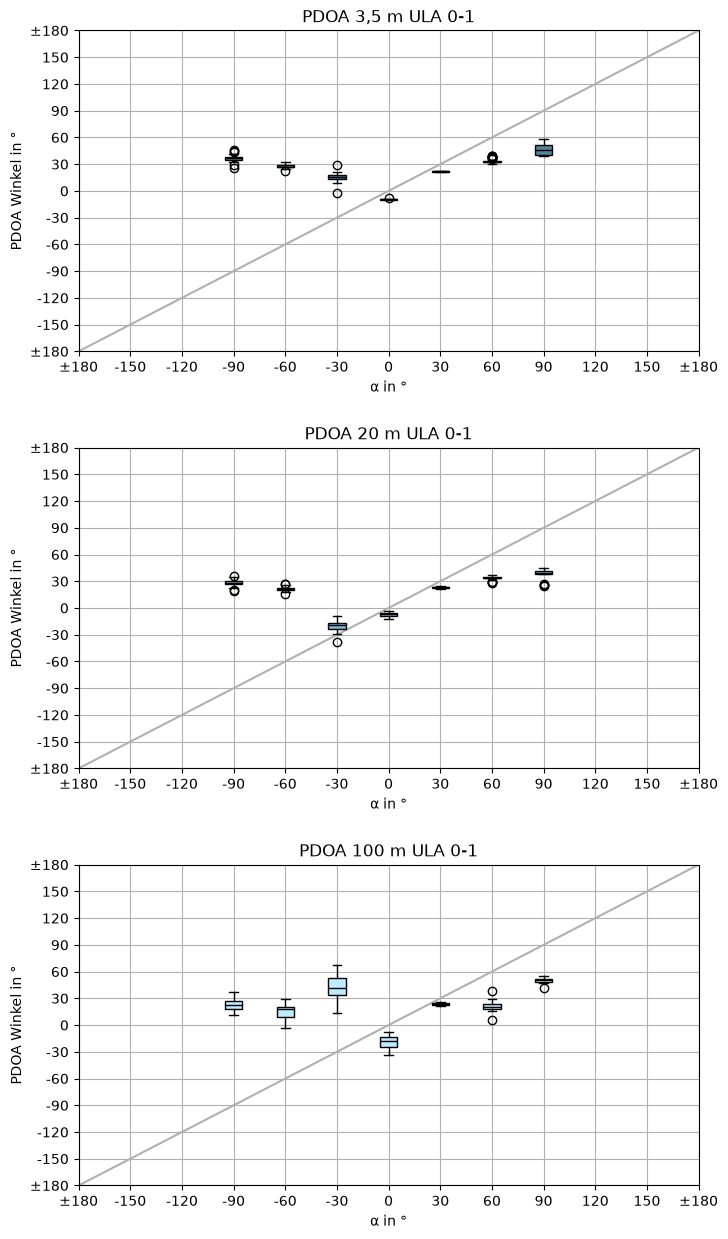

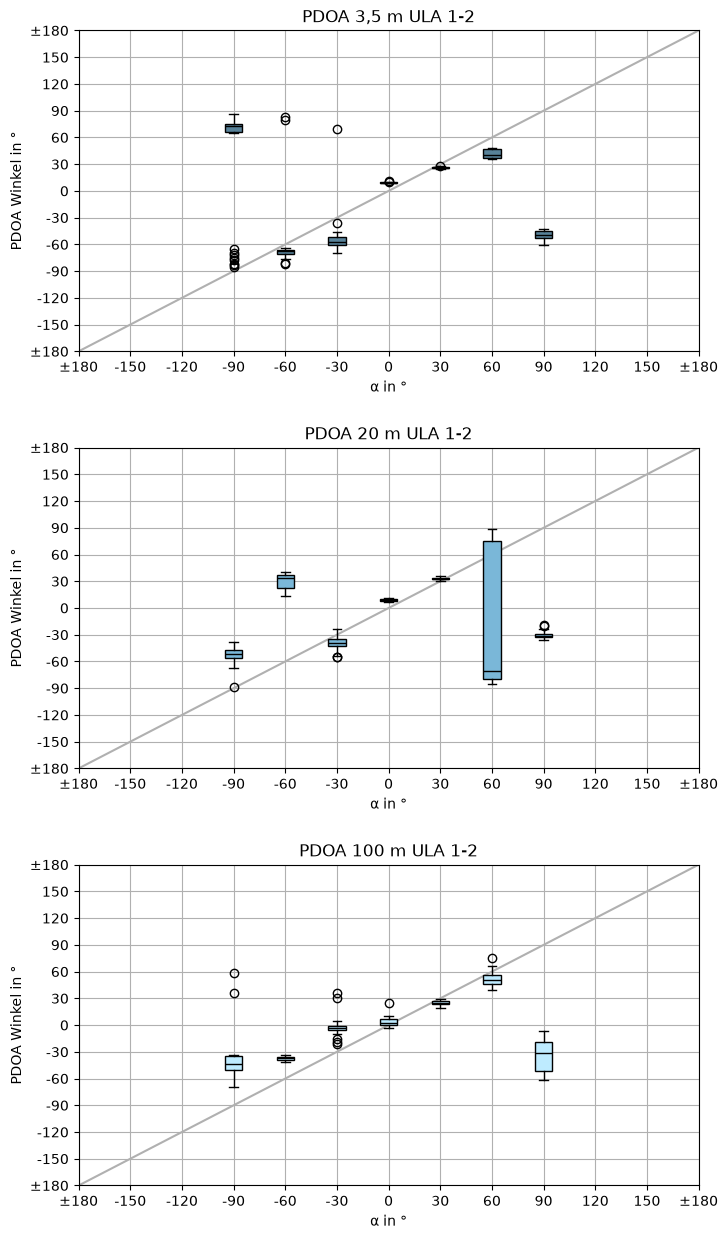

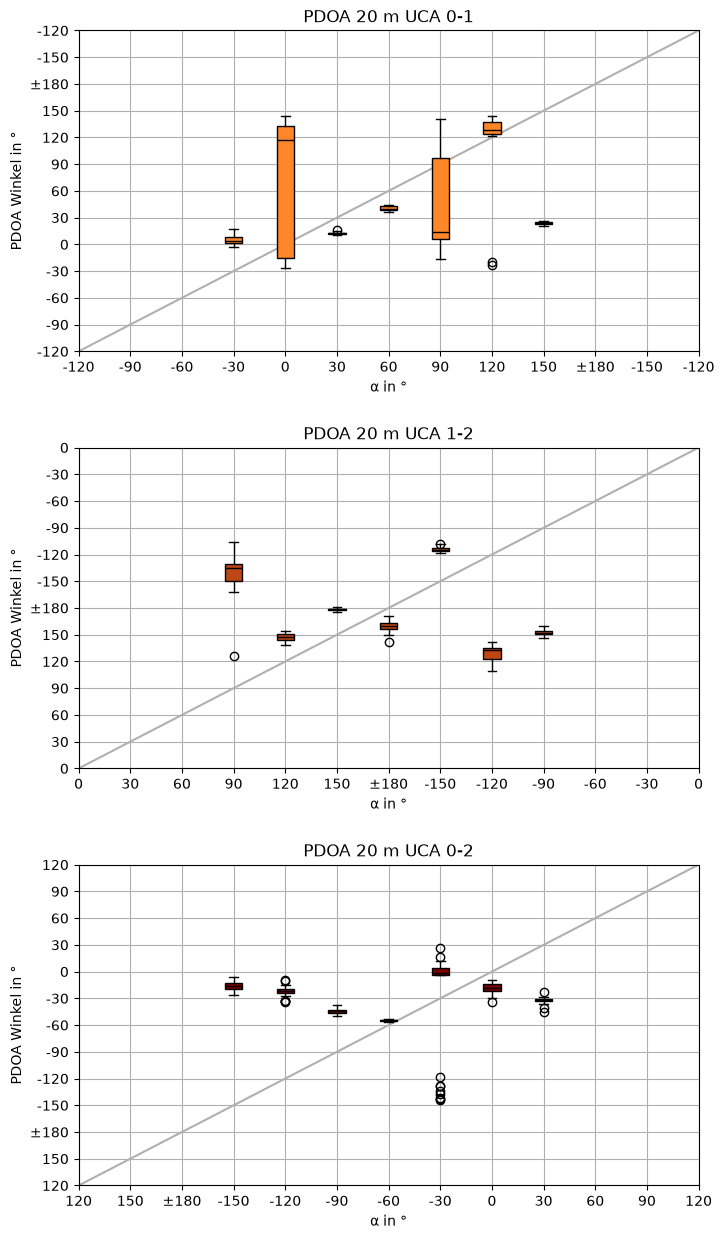

In [ ]:
# Boxplots

ula01_fig, ula01_axs = subplots(nrows=3)
ula12_fig, ula12_axs = subplots(nrows=3)
uca_fig, uca_axs = subplots(nrows=3)

figs = (ula01_fig, ula12_fig, uca_fig)
all_axes = list(ula01_axs.flatten()) + list(ula12_axs.flatten()) + list(uca_axs.flatten())

for fig in figs:
    fig.subplots_adjust(hspace=0.3)

for ax in all_axes:
    ax.set_xlabel("α in °")
    ax.set_ylabel(f"PDOA Winkel in °")
    ax.grid(True, which="major", axis="both")
    ax.plot(angles180, angles180, color='#b0b0b0')

def boxplot_pdoa(ax: Axes, scenario: Scenario, column: str, mask=None, alpha_shift = 0, **kwargs):
    if 'title' in kwargs:
        ax.set_title(kwargs['title'])
        del kwargs['title']

    series = scenario.df[column]
    if mask is not None:
        series = series.loc[series.index.isin(mask)]

    # Von den Datenpunkten den Median abziehen, dann den Boxplot berechnen
    # Das verhindert, dass die Boxplots über die +-180° Grenze hinweg "springen"
    alphas = np.array(series.index.unique())
    stats = []
    medians = []
    for alpha in alphas:
        batch = series.loc[alpha]
        median = batch.median()
        medians.append(median)
        stats.append(
            boxplot_stats(
                wrap(
                    batch - median
                ),
                # whis=(0, 100)
            )[0]
        )

    # Boxplot-stats wieder um den Median verschieben, damit die Boxplots an der richtigen Stelle liegen
    for stat, median in zip(stats, medians):
        for k in stat.keys():
            stat[k] = stat[k] + median - alpha_shift

    # zwei 360° verschobene kopien der Boxplots erstellen.
    # für den fall, dass ein Whisker über die +-180° Grenze hinausgeht, sieht es dann
    # optisch so aus, als würde der Whisker von der anderen Seite wiederkommen
    lower_batch_stat, upper_batch_stat = [], []
    for stat in stats:
        lower = stat.copy()
        upper = stat.copy()
        for k in stat.keys():
            lower[k] = stat[k] - 360
            upper[k] = stat[k] + 360
        lower_batch_stat.append(lower)
        upper_batch_stat.append(upper)
    

    defaults = {
        'label': scenario.name(),
        'widths': 10,
        # 'whis': (0, 100),
        'showfliers': True,
        'patch_artist': True,
    }
    kwargs = {**defaults, **kwargs}

    color = scenario.color()
    alphas = wrap(alphas - alpha_shift)
    alpha = 1
    if 'color' in kwargs:
        color = kwargs['color']
        del kwargs['color']
    if 'alpha' in kwargs:
        alpha = kwargs['alpha']
        del kwargs['alpha']
    mid_patch = ax.bxp(stats,           positions=alphas, **kwargs)
    if 'label' in kwargs:
        del kwargs['label']
    lo_patch = ax.bxp(lower_batch_stat, positions=alphas, **kwargs)
    hi_patch = ax.bxp(upper_batch_stat, positions=alphas, **kwargs)
    for patch in (mid_patch, lo_patch, hi_patch):
        for box in patch['boxes']:
            box.set_facecolor(color)
            box.set_alpha(alpha)
        for median in patch['medians']:
            median.set_color('black')
            # median.set_linewidth(1.5)

# ULA 3.5 m
boxplot_pdoa(ula01_axs[0], tests[0], 'pdoa01', title="PDOA 3,5 m ULA 0-1")
boxplot_pdoa(ula12_axs[0], tests[0], 'pdoa12', title="PDOA 3,5 m ULA 1-2")
# ULA 20 m
boxplot_pdoa(ula01_axs[1], tests[1], 'pdoa01', title="PDOA 20 m ULA 0-1")
boxplot_pdoa(ula12_axs[1], tests[1], 'pdoa12', title="PDOA 20 m ULA 1-2")
# ULA 100 m
boxplot_pdoa(ula01_axs[2], tests[2], 'pdoa01', title="PDOA 100 m ULA 0-1")
boxplot_pdoa(ula12_axs[2], tests[2], 'pdoa12', title="PDOA 100 m ULA 1-2")
# UCA
boxplot_pdoa(uca_axs[0], tests[3], 'pdoa01', mask=ucaRange01   , alpha_shift= 60, color=uca_colors[0])
boxplot_pdoa(uca_axs[1], tests[3], 'pdoa12', mask=ucaRange12[0], alpha_shift=180, color=uca_colors[1])
boxplot_pdoa(uca_axs[1], tests[3], 'pdoa12', mask=ucaRange12[1], alpha_shift=180, color=uca_colors[1])
boxplot_pdoa(uca_axs[2], tests[3], 'pdoa02', mask=ucaRange02   , alpha_shift=-60, color=uca_colors[2])

for ax in all_axes:
    make_x_angle(ax, angles180)
    make_y_angle(ax, angles180)

uca_axs[0].set_title("PDOA 20 m UCA 0-1")
uca_axs[1].set_title("PDOA 20 m UCA 1-2")
uca_axs[2].set_title("PDOA 20 m UCA 0-2")

uca_shifts = [
    (uca_axs[0],  60),
    (uca_axs[1], 180),
    (uca_axs[2], -60)
]

for uca_ax, alpha_shift in uca_shifts:
    angles = wrap(angles180 + alpha_shift)
    angles = ['±180' if a in (-180, 180) else str(a) for a in angles]
    uca_ax.set_xticklabels(angles)
    uca_ax.set_yticklabels(angles)    

ula01_fig.savefig("plots/PDOA_ULA01_Boxplot.pdf", bbox_inches='tight')
ula12_fig.savefig("plots/PDOA_ULA12_Boxplot.pdf", bbox_inches='tight')
uca_fig.savefig("plots/PDOA_UCA_Boxplot.pdf", bbox_inches='tight')

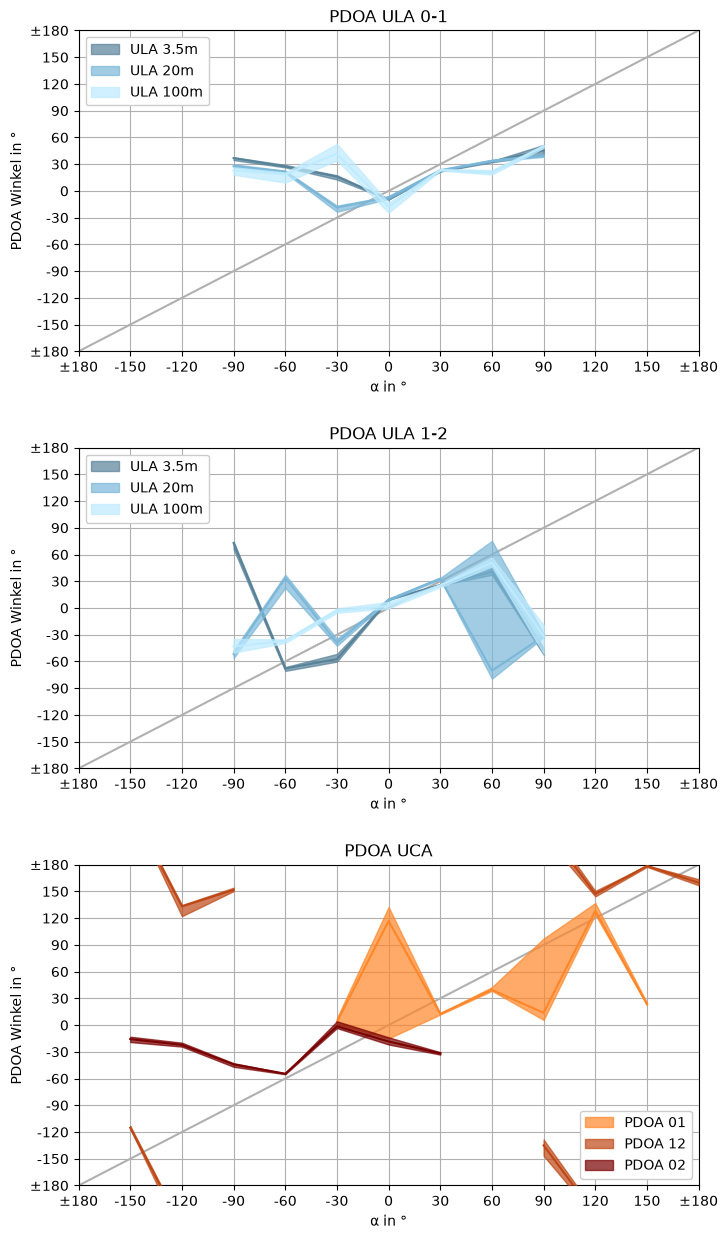

In [ ]:
# Areas
ucaRange01 = { -30, 0, 30, 60, 90, 120, 150}
ucaRange12 = ({-180, -150, -120, -90}, {90, 120, 150, 180})
ucaRange02 = {-150, -120, -90, -60, -30, 0, 30}

fig, axs = subplots(nrows=3)
fig.subplots_adjust(hspace=0.3)

for ax in axs.flatten():
    ax.sharex(axs[0])
    ax.sharey(axs[0])
    ax.set_xlabel("α in °")
    make_x_angle(ax, angles180)
    make_y_angle(ax, angles180)
    ax.plot(angles180, angles180, color='#b0b0b0')
    ax.grid(True, which="major", axis="both")
    ax.set_ylabel(f"PDOA Winkel in °")

axs[0].set_title("PDOA ULA 0-1")
axs[1].set_title("PDOA ULA 1-2")
axs[2].set_title("PDOA UCA")

zorder = 10
def plot(ax: Axes, series: pd.Series, **kwargs):
    global zorder
    analysis = pd.DataFrame(columns=['median', 'lower', 'upper'])
    for alpha in series.index.unique():
        batch = series.loc[alpha]
        # if batch has nan only, raise error
        if batch.isna().all():
            raise ValueError(f"Batch for alpha={alpha} has only NaN values: {batch}")
        analysis.loc[alpha] = (batch.median(), batch.quantile(.25), batch.quantile(.75))
    
    wrapfillquantiles(ax, analysis['median'], analysis['lower'], analysis['upper'], zorder=zorder, alpha=.7, **kwargs)
    if kwargs.get('label') is not None:
        # kwargs['label'] = '±1σ'
        del kwargs['label']
    wrapplot(ax, analysis['median'], zorder=zorder+1, **kwargs)
    zorder += 2

for scenario in tests:
    X = scenario.df.columns
    if scenario.type == 'ULA':
        plot(axs[0], scenario.df['pdoa01'], label=scenario.name(), color=scenario.color())
        plot(axs[1], scenario.df['pdoa12'], label=scenario.name(), color=scenario.color())
    else:
        plot(axs[2], scenario.df['pdoa01'].loc[scenario.df['pdoa01'].index.isin(ucaRange01)],    label="PDOA 01", color=uca_colors[0])
        plot(axs[2], scenario.df['pdoa12'].loc[scenario.df['pdoa12'].index.isin(ucaRange12[0])], label="PDOA 12", color=uca_colors[1])
        plot(axs[2], scenario.df['pdoa12'].loc[scenario.df['pdoa12'].index.isin(ucaRange12[1])],                  color=uca_colors[1])
        plot(axs[2], scenario.df['pdoa02'].loc[scenario.df['pdoa02'].index.isin(ucaRange02)],    label="PDOA 02", color=uca_colors[2])

for ax in axs:
    legend(ax)

fig.savefig("plots/PDOA_QuantileArea_vs_Alpha.pdf", bbox_inches="tight")

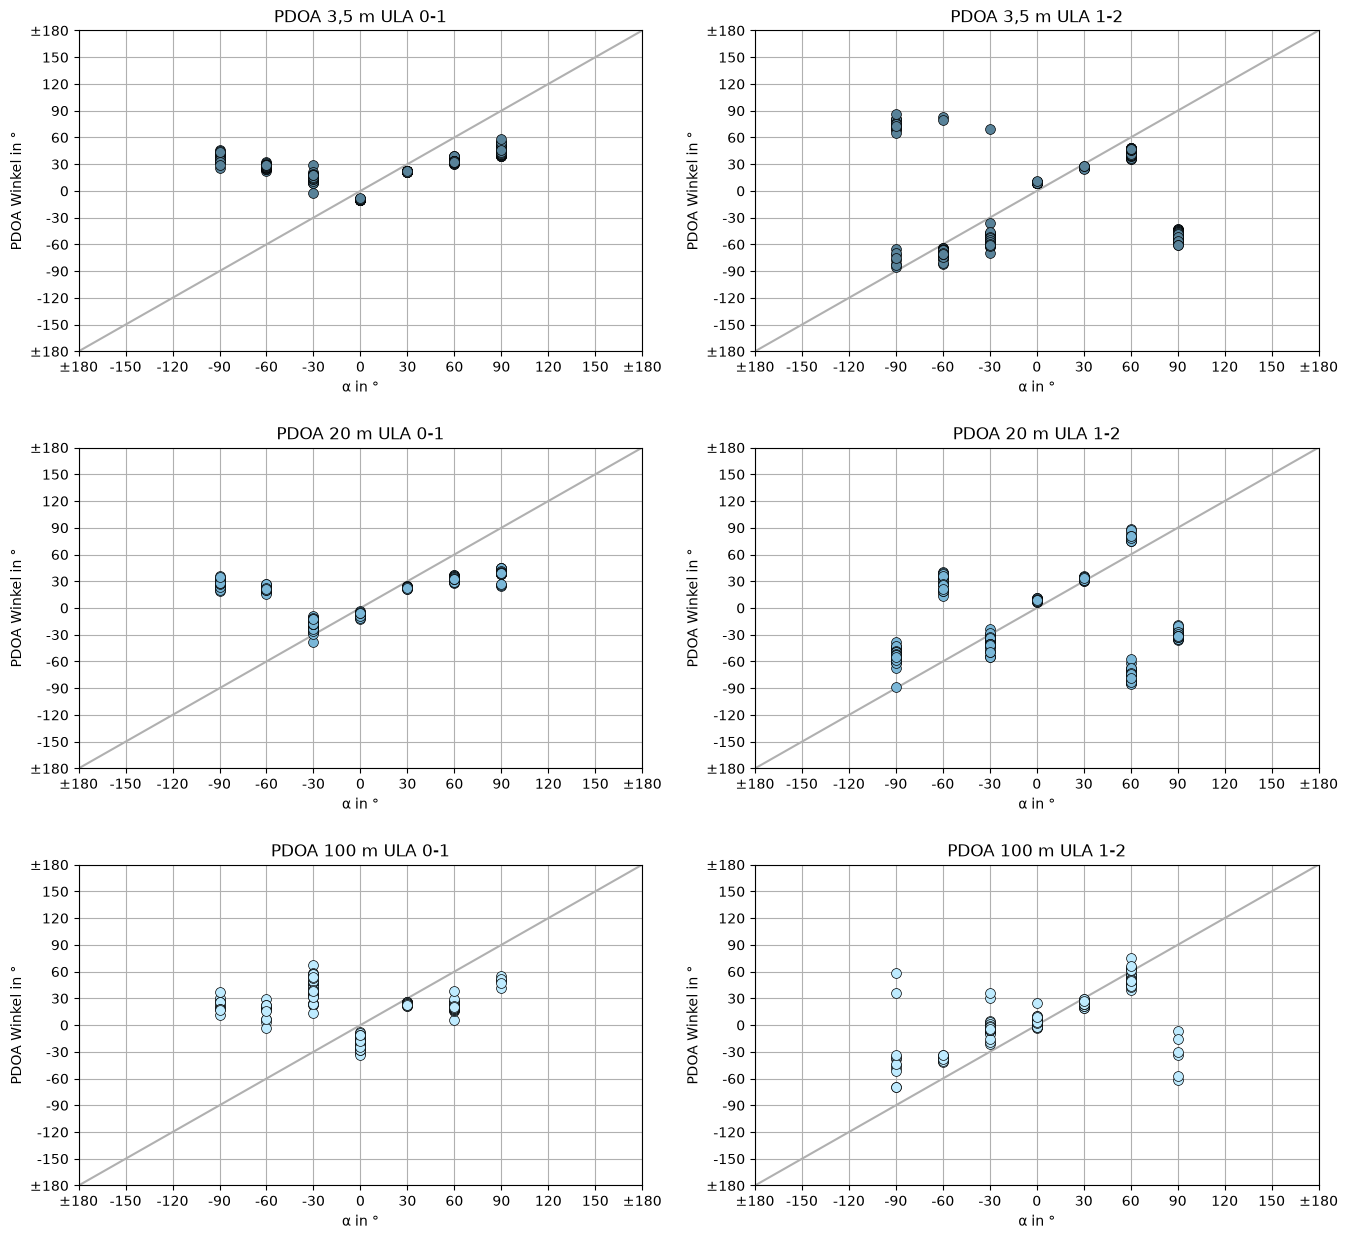

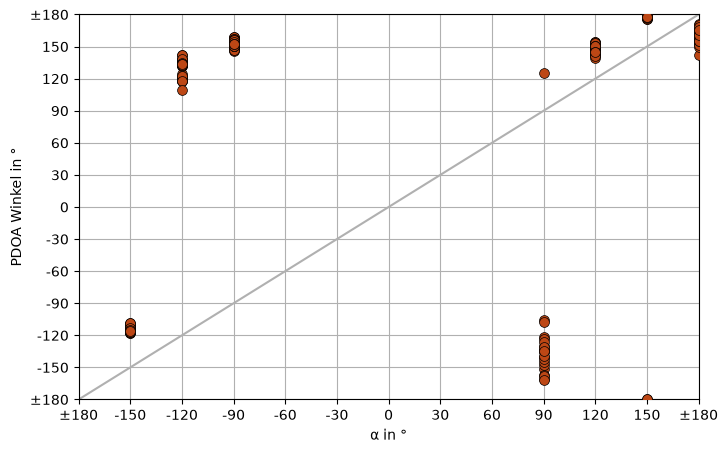

In [ ]:
# Scatter

ucaRange01 = { -30, 0, 30, 60, 90, 120, 150}
ucaRange12 = ({-180, -150, -120, -90}, {90, 120, 150, 180})
ucaRange02 = {-150, -120, -90, -60, -30, 0, 30}

ula_fig, ula_axs = subplots(nrows=3, ncols=2)
ula_fig.subplots_adjust(hspace=0.3)
uca_fig, uca_ax  = subplots()
uca_ax: Axes

for ax in list(ula_axs.flatten()) + [uca_ax]:
    ax: Axes
    ax.set_xlabel("α in °")
    make_x_angle(ax, angles180)
    make_y_angle(ax, angles180)
    ax.plot(angles180, angles180, color='#b0b0b0', zorder=-1)
    ax.grid(True, which="major", axis="both")
    ax.set_ylabel(f"PDOA Winkel in °")

def scatter(ax: Axes, series: pd.Series, **kwargs):
    if 'title' in kwargs:
        ax.set_title(kwargs['title'])
        del kwargs['title']
    default = {
        's': 50,
        'linewidths' : 0.5,
        'edgecolors' : 'black',
        'zorder': 10
    }
    kwargs = {**default, **kwargs}
    ax.scatter(series.index, series.values, **kwargs)    

# ULA 3.5 m
scatter(ula_axs[0,0], tests[0].df['pdoa01'], title="PDOA 3,5 m ULA 0-1", color=tests[0].color())
scatter(ula_axs[0,1], tests[0].df['pdoa12'], title="PDOA 3,5 m ULA 1-2", color=tests[0].color())
# ULA 20 m
scatter(ula_axs[1,0], tests[1].df['pdoa01'], title="PDOA 20 m ULA 0-1", color=tests[1].color())
scatter(ula_axs[1,1], tests[1].df['pdoa12'], title="PDOA 20 m ULA 1-2", color=tests[1].color())
# ULA 100 m
scatter(ula_axs[2,0], tests[2].df['pdoa01'], title="PDOA 100 m ULA 0-1", color=tests[2].color())
scatter(ula_axs[2,1], tests[2].df['pdoa12'], title="PDOA 100 m ULA 1-2", color=tests[2].color())
# UCA
# scatter(uca_ax, tests[3].df['pdoa01'].loc[tests[3].df['pdoa01'].index.isin(ucaRange01)],    color=uca_colors[0])
scatter(uca_ax, tests[3].df['pdoa12'].loc[tests[3].df['pdoa12'].index.isin(ucaRange12[0])], color=uca_colors[1])
scatter(uca_ax, tests[3].df['pdoa12'].loc[tests[3].df['pdoa12'].index.isin(ucaRange12[1])], color=uca_colors[1])
# scatter(uca_ax, tests[3].df['pdoa02'].loc[tests[3].df['pdoa02'].index.isin(ucaRange02)],    color=uca_colors[2])


ula_fig.savefig("plots/PDOA_ULA_Scatter_vs_Alpha.pdf", bbox_inches="tight")
uca_fig.savefig("plots/PDOA_UCA_Scatter_vs_Alpha.pdf", bbox_inches="tight")

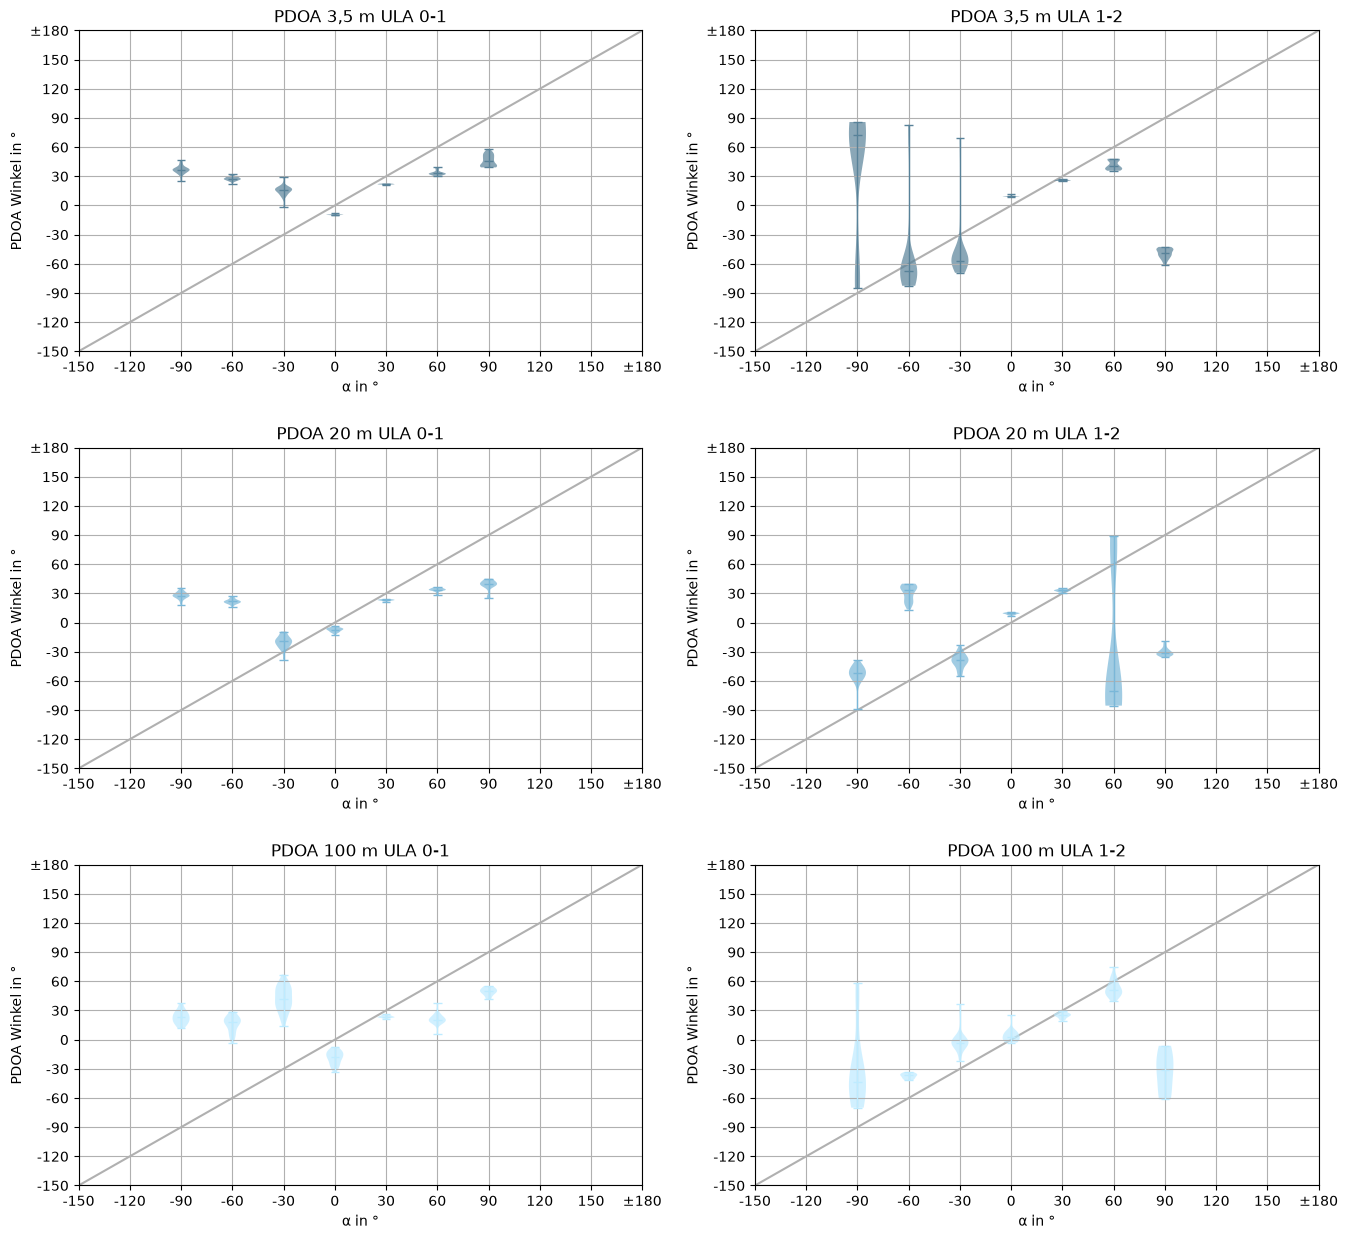

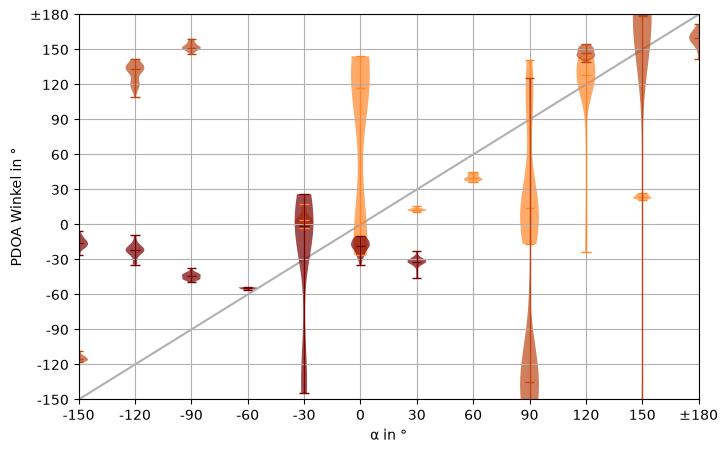

In [ ]:
# Violins

ucaRange01 = { -30, 0, 30, 60, 90, 120, 150}
ucaRange12 = ({-180, -150, -120, -90}, {90, 120, 150, 180})
ucaRange02 = {-150, -120, -90, -60, -30, 0, 30}

ula_fig, ula_axs = subplots(nrows=3, ncols=2)
ula_fig.subplots_adjust(hspace=0.3)
uca_fig, uca_ax  = subplots()
uca_ax: Axes

angles180 = tests[-1].df.index.unique()
for ax in list(ula_axs.flatten()) + [uca_ax]:
    ax: Axes
    ax.set_xlabel("α in °")
    make_x_angle(ax, angles180)
    make_y_angle(ax, angles180)
    ax.plot(angles180, angles180, color='#b0b0b0', zorder=-1)
    ax.grid(True, which="major", axis="both")
    ax.set_ylabel(f"PDOA Winkel in °")

def violin(ax: Axes, series: pd.Series, **kwargs):
    if 'title' in kwargs:
        ax.set_title(kwargs.pop('title'))

    alphas = series.index.unique()
    pairs = []
    for a in alphas:
        values = np.atleast_1d(series.loc[a]).astype(float)
        values = values[~np.isnan(values)]
        if values.size > 0:
            pairs.append((values, a))

    if not pairs:
        return

    data, positions = zip(*pairs)
    parts = ax.violinplot(data, positions=positions, widths=10, showmedians=True)

    color = kwargs.get('color')
    if color is not None:
        for body in parts['bodies']:
            body.set_facecolor(color)
            # body.set_edgecolor(color)
            # body.set_linewidth(1.0)
            body.set_alpha(0.7)

        for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            if key in parts:
                parts[key].set_color(color)
                parts[key].set_linewidth(1.0)

# ULA 3.5 m
violin(ula_axs[0,0], tests[0].df['pdoa01'], title="PDOA 3,5 m ULA 0-1", color=tests[0].color())
violin(ula_axs[0,1], tests[0].df['pdoa12'], title="PDOA 3,5 m ULA 1-2", color=tests[0].color())
# ULA 20 m
violin(ula_axs[1,0], tests[1].df['pdoa01'], title="PDOA 20 m ULA 0-1", color=tests[1].color())
violin(ula_axs[1,1], tests[1].df['pdoa12'], title="PDOA 20 m ULA 1-2", color=tests[1].color())
# ULA 100 m
violin(ula_axs[2,0], tests[2].df['pdoa01'], title="PDOA 100 m ULA 0-1", color=tests[2].color())
violin(ula_axs[2,1], tests[2].df['pdoa12'], title="PDOA 100 m ULA 1-2", color=tests[2].color())
# UCA
violin(uca_ax, tests[3].df['pdoa01'].loc[tests[3].df['pdoa01'].index.isin(ucaRange01)],    color=uca_colors[0])
violin(uca_ax, tests[3].df['pdoa12'].loc[tests[3].df['pdoa12'].index.isin(ucaRange12[0])], color=uca_colors[1])
violin(uca_ax, tests[3].df['pdoa12'].loc[tests[3].df['pdoa12'].index.isin(ucaRange12[1])], color=uca_colors[1])
violin(uca_ax, tests[3].df['pdoa02'].loc[tests[3].df['pdoa02'].index.isin(ucaRange02)],    color=uca_colors[2])
# uca_ax.vlines([-60, 60, 180, -180], -180, 180)

# for ax in list(ula_axs.flatten()) + [uca_ax]:
#     legend(ax)

ula_fig.savefig("plots/PDOA_ULA_Violins_vs_Alpha.pdf", bbox_inches="tight")
uca_fig.savefig("plots/PDOA_UCA_Violins_vs_Alpha.pdf", bbox_inches="tight")
